In [1]:
from typing import TypedDict 
from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display
from dotenv import load_dotenv
import os

load_dotenv()

True

In [2]:
#states

class State(TypedDict):
    user_request: str
    analysis_results: str

In [3]:
#nodes

def planning_node(state: State) -> State:
    return {
        'user_request': state['user_request'],
        'analysis_results': 'hi'
            }

In [4]:
builder = StateGraph(State, input_schema=State, output_schema=State)

#nodes
builder.add_node('planning_node', planning_node)

#edges
builder.add_edge(START, 'planning_node')
builder.add_edge('planning_node', END)


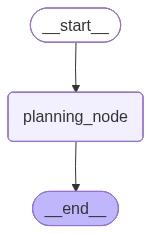

In [5]:
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
graph.invoke({'user_request': 'by', 'analysis_results': ''})

{'user_request': 'by', 'analysis_results': 'hi'}

In [1]:

from langchain_mcp_adapters.client import MultiServerMCPClient
from spm_agent.config import SCIFIREADERS_MCP_COMMAND

In [2]:
SCIFIREADERS_MCP_COMMAND

PosixPath('/Users/borisslautin/Documents/GitHub/SPM_agent_simple/.venv/bin/scifireaders_mcp')

In [3]:
client = MultiServerMCPClient(
            {
                "scifireaders": {
                    "transport": "stdio",
                    "command": str(SCIFIREADERS_MCP_COMMAND),
                    "args": [],
                }
            }
        )

In [5]:
tools = await client.get_tools()

In [6]:
tools

[StructuredTool(name='list_readers', description='List the SciFiReaders reader classes currently available in this environment.', args_schema={'properties': {}, 'title': 'list_readers_toolArguments', 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x105222050>),
 StructuredTool(name='read_file', description='Read a scientific file with the best available SciFiReaders reader.', args_schema={'properties': {'file_path': {'title': 'File Path', 'type': 'string'}, 'return_mode': {'default': 'file', 'title': 'Return Mode', 'type': 'string'}}, 'required': ['file_path'], 'title': 'read_file_toolArguments', 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x10d0c5b40>),
 StructuredTool(name='read_scifireaders_file', description='Read a scientific file with the best available SciFiReaders reader.', args_schema={'properties':

In [7]:
read_file_tool = next(
    tool for tool in tools
    if tool.name == "read_file"
)

In [8]:
print(read_file_tool.name)
print(read_file_tool.description)
print(read_file_tool.args)

read_file
Read a scientific file with the best available SciFiReaders reader.
{'file_path': {'title': 'File Path', 'type': 'string'}, 'return_mode': {'default': 'file', 'title': 'Return Mode', 'type': 'string'}}


In [9]:
result = await read_file_tool.ainvoke(
    {
        "file_path": "/Users/borisslautin/Downloads/plzt_0004.ibw",
        "return_mode": "file",
    }
)



ToolException: Error executing tool read_file: Object of type bytes is not JSON serializable

In [9]:
import inspect
import SciFiReaders.mcp.scifireaders_mcp as mcp_server

print(mcp_server.__file__)
print(inspect.getsource(mcp_server.read_file))

/Users/borisslautin/Documents/GitHub/SPM_agent_simple/.venv/lib/python3.10/site-packages/SciFiReaders/mcp/scifireaders_mcp.py
def read_file(file_path: str, return_mode: str = "file") -> Dict[str, Any]:
    """
    Read a file with the appropriate SciFiReaders reader.

    The payload includes:
    - ``available_readers``: all registered readers in the package
    - ``matched_readers``: readers that reported they could read the file
    - ``selected_reader``: the reader that was actually used
    - ``output_file_path``: generated NeXus HDF5 path containing exported datasets
    - ``datasets``: serialized dataset payloads when inline output is requested

    Parameters
    ----------
    file_path : str
        Source file to read.
    return_mode : str, optional
        One of ``"file"``, ``"data"``, or ``"both"``.
    """
    if return_mode not in {"file", "data", "both"}:
        raise ValueError("return_mode must be one of: 'file', 'data', 'both'")

    reader_cls, matched_readers = 

In [6]:
from SciFiReaders.mcp.scifireaders_mcp import read_file
import json

payload = read_file(
    r"/Users/borisslautin/Downloads/PLZT_0007.ibw",
    return_mode="data",
)

json.dumps(payload)

TypeError: Object of type bytes is not JSON serializable

In [7]:
def find_bytes(obj, path="root"):
    if isinstance(obj, bytes):
        print(f"BYTES at {path}: {obj[:100]!r}")
        return

    if isinstance(obj, dict):
        for k, v in obj.items():
            if isinstance(k, bytes):
                print(f"BYTES key at {path}: {k[:100]!r}")
            find_bytes(v, f"{path}.{k}")

    elif isinstance(obj, (list, tuple, set)):
        for i, v in enumerate(obj):
            find_bytes(v, f"{path}[{i}]")


find_bytes(payload)

BYTES at root.datasets.Channel_000.original_metadata.other_parms.whpad1[0]: b''
BYTES at root.datasets.Channel_000.original_metadata.other_parms.whpad1[1]: b''
BYTES at root.datasets.Channel_000.original_metadata.other_parms.whpad1[2]: b''
BYTES at root.datasets.Channel_000.original_metadata.other_parms.whpad1[3]: b''
BYTES at root.datasets.Channel_000.original_metadata.other_parms.whpad1[4]: b'\x03'
BYTES at root.datasets.Channel_000.original_metadata.other_parms.whpad1[5]: b'\x03'
BYTES at root.datasets.Channel_000.original_metadata.other_parms.dataUnits[0]: b'm'
BYTES at root.datasets.Channel_000.original_metadata.other_parms.dataUnits[1]: b''
BYTES at root.datasets.Channel_000.original_metadata.other_parms.dataUnits[2]: b''
BYTES at root.datasets.Channel_000.original_metadata.other_parms.dataUnits[3]: b''
BYTES at root.datasets.Channel_000.original_metadata.other_parms.dimUnits[0][0]: b's'
BYTES at root.datasets.Channel_000.original_metadata.other_parms.dimUnits[0][1]: b''
BYTES at

In [5]:
result = await read_file_tool.ainvoke(
    {
        "file_path": r"/Users/borisslautin/Downloads/plzt_0004.ibw",
        "return_mode": 'data'

    }
)

NameError: name 'read_file_tool' is not defined

In [38]:
result[0]

{'type': 'text',
 'text': '{\n  "file_path": "/Users/borisslautin/Downloads/plzt_0004.ibw",\n  "return_mode": "data",\n  "available_readers": [\n    {\n      "name": "DMReader",\n      "module": "SciFiReaders.readers.microscopy.em.tem.dm_reader",\n      "doc": "Reader of Digital Micrograph image and spectroscopy data"\n    },\n    {\n      "name": "DM3Reader",\n      "module": "SciFiReaders.readers.microscopy.em.tem.dm_reader",\n      "doc": "DM3 file reader class."\n    },\n    {\n      "name": "NionReader",\n      "module": "SciFiReaders.readers.microscopy.em.tem.nion_reader",\n      "doc": "Reader for Nion ndata and h5 files"\n    },\n    {\n      "name": "EMDReader",\n      "module": "SciFiReaders.readers.microscopy.em.tem.emd_reader",\n      "doc": "Creates an instance of EMDReader which can read one or more HDF5"\n    },\n    {\n      "name": "MRCReader",\n      "module": "SciFiReaders.readers.microscopy.em.tem.mrc_reader",\n      "doc": ""\n    },\n    {\n      "name": "EDAXRead